In [8]:
%load_ext autoreload
%autoreload 2
from src import utils
from src import repaint_base, repaint_improve_jumps, repaint_improved_blur, repaint_improved_average

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


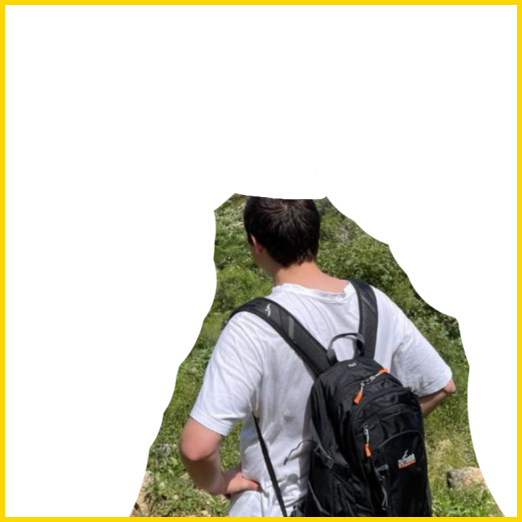

In [2]:
img = utils.open_image("p_0.png")
mask = utils.open_mask("mask_forest.png")
utils.mask_image(img.copy(), mask.copy())

In [3]:
from diffusers import StableDiffusionPipeline, DDPMScheduler
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "sd2-community/stable-diffusion-2-base"
pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16
    ).to(device)

pipe.scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

base implementation based on the article

beginning impainting


100%|██████████| 1000/1000 [02:32<00:00,  6.57it/s]


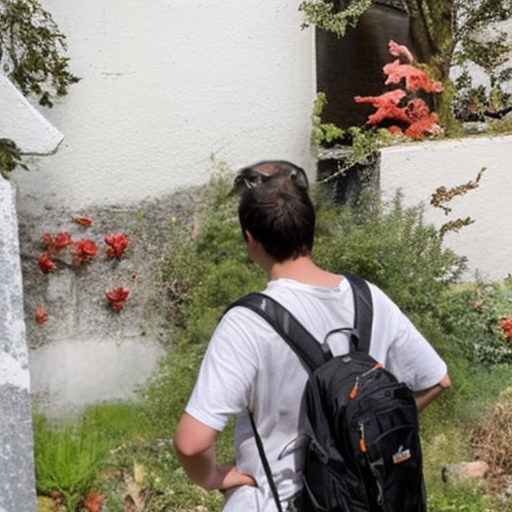

In [4]:
r = repaint_base.RePaintBase(pipe)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

r.impaint(img,mask,"a picture of a bush").show()

base implementation based on the article with minor improvments to the jump logic

beginning impainting


100%|██████████| 1000/1000 [02:30<00:00,  6.64it/s]


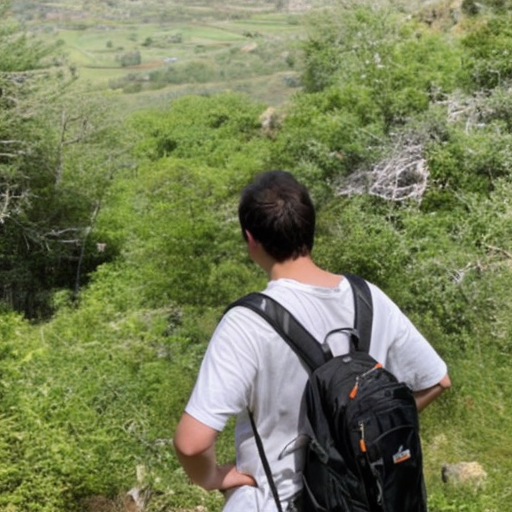

In [5]:
r = repaint_improve_jumps.RePaintImproved(pipe)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

r.impaint(img,mask,"a picture of a bush").show()

blur addition

beginning impainting


100%|██████████| 1000/1000 [02:31<00:00,  6.59it/s]


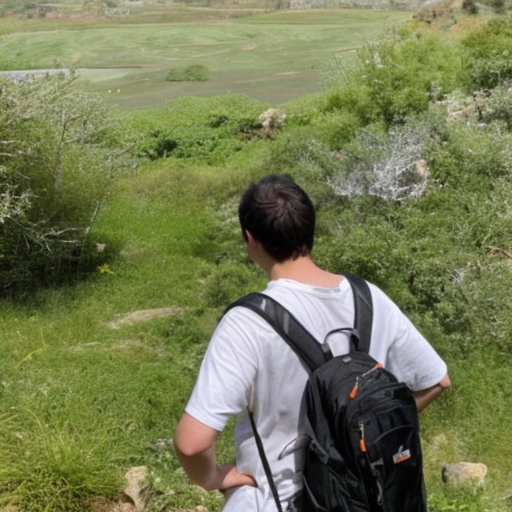

In [6]:
r = repaint_improved_blur.RePaintImprovedBlur(pipe)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

r.impaint(img,mask,"a picture of a bush").show()

improved with averaging over the predicted noise

In [ ]:
r = repaint_improved_average.RePaintImprovedAverage(pipe,3)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

r.impaint(img,mask,"a picture of a bush").show()

beginning impainting


 22%|██▎       | 225/1000 [01:31<02:51,  4.53it/s]